In [ ]:
print('hello')

In [2]:
import pandas as pd
df = pd.read_csv('dataset.csv')
df.head()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [3]:
print(df.head())

   Unnamed: 0        open        high         low       close  volume  \
0           0  112.900002  118.800003  107.142998  115.910004     0.0   
1           1    3.493130    3.692460    3.346060    3.590890     0.0   
2           2  115.980003  124.663002  106.639999  112.300003     0.0   
3           3    3.594220    3.781020    3.116020    3.371250     0.0   
4           4  112.250000  113.444000   97.699997  111.500000     0.0   

      marketCap                 timestamp crypto_name        date  
0  1.288693e+09  2013-05-05T23:59:59.999Z     Bitcoin  2013-05-05  
1  6.229819e+07  2013-05-05T23:59:59.999Z    Litecoin  2013-05-05  
2  1.249023e+09  2013-05-06T23:59:59.999Z     Bitcoin  2013-05-06  
3  5.859436e+07  2013-05-06T23:59:59.999Z    Litecoin  2013-05-06  
4  1.240594e+09  2013-05-07T23:59:59.999Z     Bitcoin  2013-05-07  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   72946 non-null  int64  
 1   open         72946 non-null  float64
 2   high         72946 non-null  float64
 3   low          72946 non-null  float64
 4   close        72946 non-null  float64
 5   volume       72946 non-null  float64
 6   marketCap    72946 non-null  float64
 7   timestamp    72946 non-null  object 
 8   crypto_name  72946 non-null  object 
 9   date         72946 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 5.6+ MB


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   72946 non-null  int64  
 1   open         72946 non-null  float64
 2   high         72946 non-null  float64
 3   low          72946 non-null  float64
 4   close        72946 non-null  float64
 5   volume       72946 non-null  float64
 6   marketCap    72946 non-null  float64
 7   timestamp    72946 non-null  object 
 8   crypto_name  72946 non-null  object 
 9   date         72946 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 5.6+ MB
None


In [6]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df = df.dropna()


In [8]:
#1. Daily returns
import numpy as np
df['return'] = np.log(df['close'] / df['close'].shift(1))

In [9]:
# 2.volatility
df['volatility'] = df['return'].rolling(7).std()

In [10]:
#3.moving averages
df['MA7']=df['close'].rolling(7).mean()
df['MA14']=df['close'].rolling(14).mean()

In [11]:
#4.volume ratio
df['vol_ratio']=df['volume']/df['marketCap']

In [12]:
df = df.dropna()

In [13]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

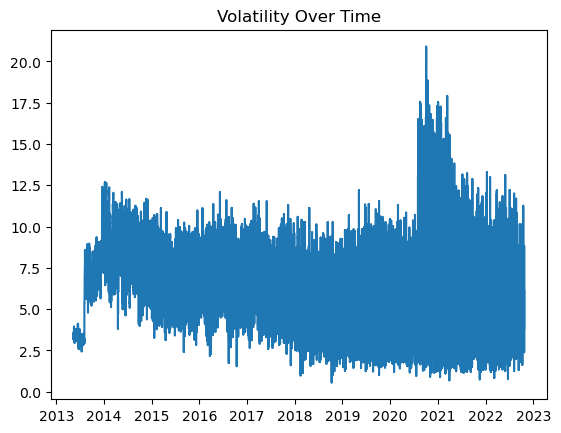

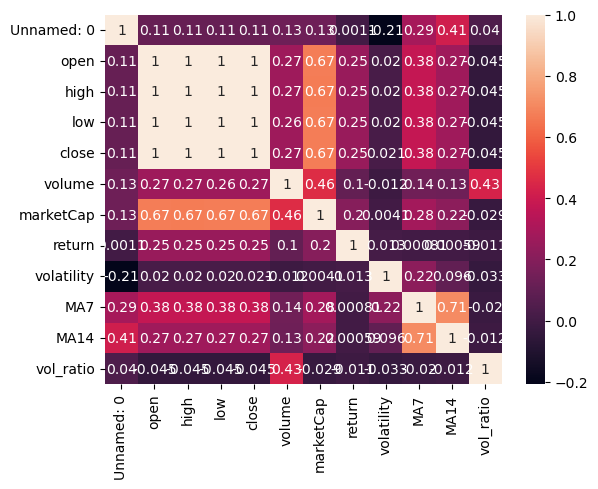

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# volatility plot
plt.plot(df['date'], df['volatility'])
plt.title("Volatility Over Time")
plt.show()

# Correlation
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [15]:
# Model Training

features = ['open', 'high', 'low', 'close', 'volume', 'marketCap', 'MA7', 'MA14', 'vol_ratio']
X = df[features]
y = df['volatility']

In [16]:
from sklearn.model_selection import train_test_split
x_train , x_test ,y_train , y_test   =  train_test_split( X , y , test_size= 0.20 , random_state=1)

In [18]:
import numpy as np

print(np.isinf(x_train).sum())

open            0
high            0
low             0
close           0
volume          0
marketCap       0
MA7             0
MA14            0
vol_ratio    1891
dtype: int64


In [19]:

x_train = x_train.replace([np.inf, -np.inf], np.nan)
x_test = x_test.replace([np.inf, -np.inf], np.nan)

In [20]:
x_train = x_train.fillna(x_train.mean())
x_test = x_test.fillna(x_test.mean())

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [22]:
import numpy as np

df['volume'] = np.log1p(df['volume'])
df['marketCap'] = np.log1p(df['marketCap'])
df['close'] = np.log1p(df['close'])

In [23]:
from sklearn.ensemble import RandomForestRegressor 
model = RandomForestRegressor()

In [24]:
model

RandomForestRegressor()

In [25]:
model.fit(x_train, y_train)

RandomForestRegressor()

In [26]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
y_pred = model.predict(x_test)

print("RMSE:",np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

RMSE: 1.8777391134920742
MAE: 1.3054866584772984
R2: 0.28443396932920073


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

ModuleNotFoundError: No module named 'xgboost'